# IMU signal analysis, dataset creation and autoencoder design for stillness detection

## An exploration related with IMU data from a low-cost MPU6050 and BNO0080 for displacement measurement and stillness detection.
MSc. Cristian Yarib Bautista

In [1]:
import socket
import keyboard
import time
import matplotlib.pyplot as plt
import numpy as np

## 1 data gathering + math analysis

In [6]:
UDP_IP = "0.0.0.0"
UDP_PORT = 1234
DURATION = 5      # seconds to display in plot
SAMPLE_PERIOD = 0.01    # 10 ms between samples

In [ ]:
print(f"Listening for MPU6050 data on port {UDP_PORT}...")
def filter (actual, previous):
    alpha = 0.5
    return actual*(1-alpha) + alpha*previous

print("Gathering data")
timestamps, ax, ay, az, rx, ry, rz = [], [], [], [], [], [], []
pax, pay, paz = 0,0,0
sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
sock.settimeout(10.0)
sock.bind((UDP_IP, UDP_PORT))
t0 = time.time()
while time.time() - t0 < DURATION:
    data, addr = sock.recvfrom(1024)
    try:
        decoded = data.decode().strip()
        values = [float(v) for v in decoded.split(",")]
        #print(f"Received from {addr}: {values}")

        if len(values) == 6:
            ts = time.time() - t0
            timestamps.append(ts)
            ax.append(filter(values[0], pax)); ay.append(filter(values[1], pay)); az.append(filter(values[2], paz))
            rx.append(values[3]); ry.append(values[4]); rz.append(values[5])

            pax, pay, paz = values[0], values[1], values[2]
        #time.sleep(0.005)

        if keyboard.is_pressed('q'):
            print("You pressed the 'q' key!")
            sock.close()
            break
    except Exception as e:
        print(f"Decode error: {e}, raw data: {data}")

print(f"Received {len(timestamps)} samples.")
sock.close()

Listening for MPU6050 data on port 1234...
Gathering data
Received 502 samples.


## Time signal analysis

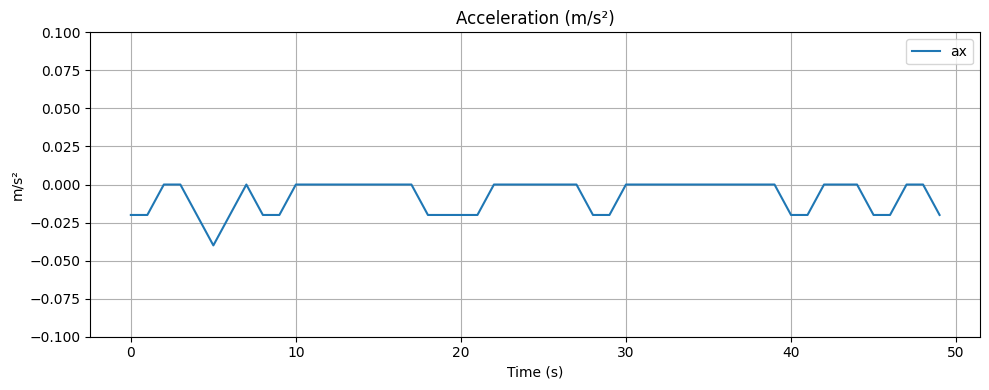

In [20]:
# block_size = 5
# ax_demean = ax.copy()
# for i in range(0, len(ax), block_size):
#     block = ax[i:i+block_size]
#     ax_demean[i:i+block_size] = block - np.mean(block)
# --- plotting ---
ax_filt = np.array(ax)
#ax_filt[np.abs(ax_filt) < 0.8] = 0
## Option A: Plot acceleration only
n = 50
offset = 0*n
plt.figure(figsize=(10, 4))
plt.plot(ax_filt[offset:offset+n], label="ax")
#plt.plot(timestamps[offset:offset+n], ay[offset:offset+n], label="ay")
#plt.plot(timestamps[offset:offset+n], az[offset:offset+n], label="az")
plt.title("Acceleration (m/s²)")
plt.xlabel("Time (s)")
plt.ylabel("m/s²")
plt.legend()
plt.grid(True)

#plt.xlim(0, DURATION)
plt.ylim(-0.1, .1)
plt.tight_layout()
plt.show()

0.0 0.0


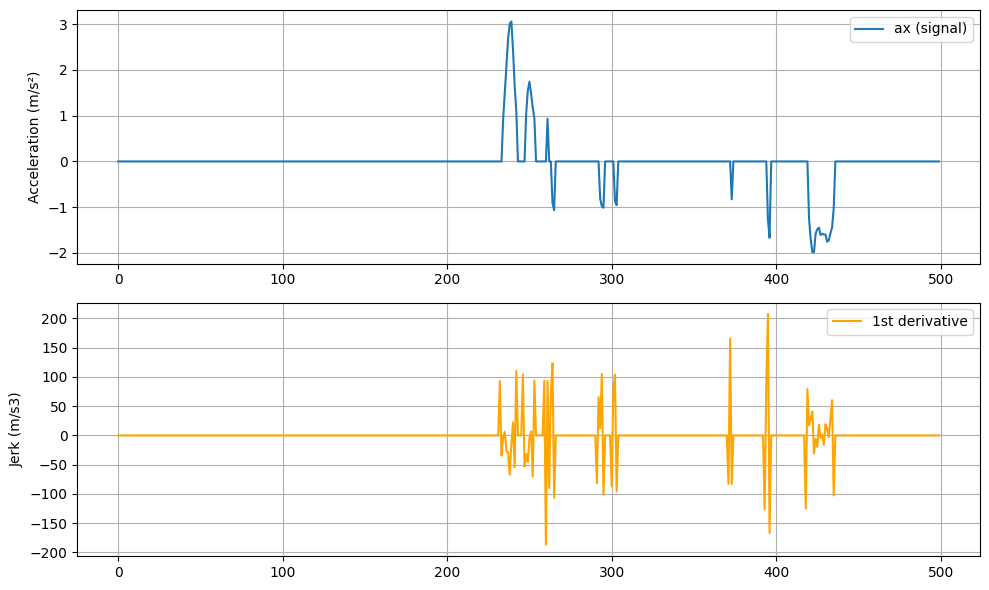

In [ ]:
##cuación de diferencias x[n]-x[n-1]

signal = ax_filt
dt = 0.01  # sampling interval (seconds)
t = np.arange(len(signal)) * dt

diffTimes = 2
# --- derivatives ---
sample = 3
print(signal[sample], signal[sample-1])

j = np.diff(signal, n=diffTimes)/dt     # first derivative (jerk)
#j = np.abs(j)
#j = np.gradient(signal, dt)      # second derivative (snap)

# --- plotting ---
plt.figure(figsize=(10,6))
n = 500
offset = 0
plt.subplot(2,1,1)
#plt.plot(t[offset:offset+n], ax[offset:offset+n], label="ax (signal)")
plt.plot(signal[offset:offset+n], label="ax (signal)")
plt.ylabel("Acceleration (m/s²)")
plt.legend(); plt.grid(True)

plt.subplot(2,1,2)
#plt.plot(t[offset:offset+n], j[offset:offset+n], label="1st derivative", color='orange')
plt.plot(j[offset:offset+n], label="1st derivative", color='orange')
plt.ylabel("Jerk (m/s3)")
plt.legend(); plt.grid(True)

# plt.subplot(3,1,3)
# plt.plot(t[1:], s, label="2nd derivative", color='green')
# plt.xlabel("Time (s)")
# plt.ylabel("Snap (m/s4)")
# plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

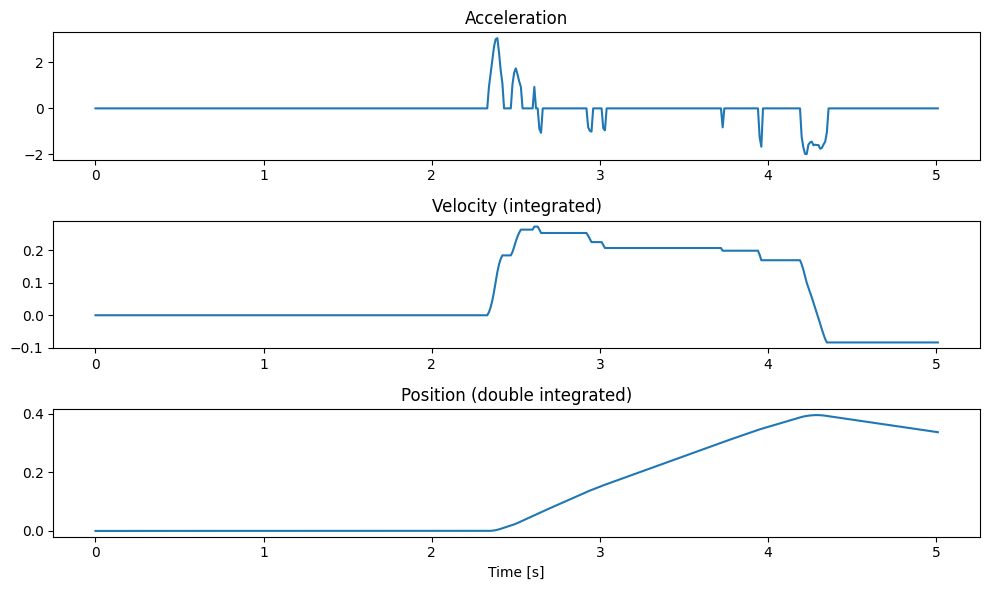

In [89]:
# Integration (discrete)
v = np.cumsum(ax_filt) * dt   # integrate acceleration → velocity
x = np.cumsum(v) * dt    # integrate velocity → position

# Plot results
plt.figure(figsize=(10,6))
plt.subplot(3,1,1)
plt.plot(t, ax_filt)
plt.title("Acceleration")

plt.subplot(3,1,2)
plt.plot(t, v)
plt.title("Velocity (integrated)")

plt.subplot(3,1,3)
plt.plot(t, x)
plt.title("Position (double integrated)")

plt.xlabel("Time [s]")
plt.tight_layout()
plt.show()

-0.00021000000000000006 -0.0003800000000000001


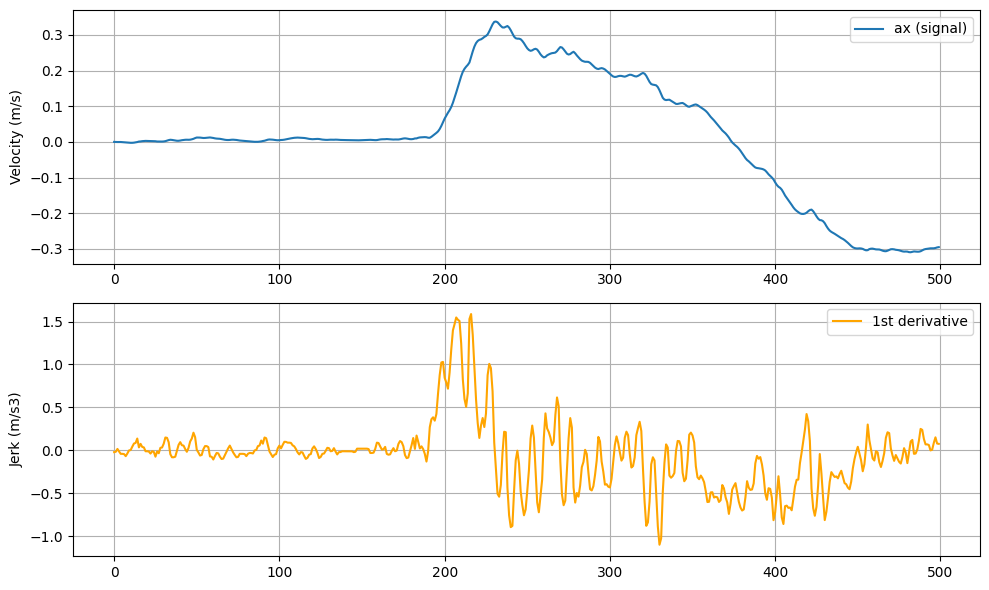

In [ ]:
#Ecuación de diferencias para la velocidad

signal = v
dt = 0.01  # sampling interval (seconds)
t = np.arange(len(signal)) * dt

diffTimes = 1
# --- derivatives ---
sample = 3
print(signal[sample], signal[sample-1])

j = np.diff(signal, n=diffTimes)/dt     # first derivative (jerk)
#j = np.abs(j)
#j = np.gradient(signal, dt)      # second derivative (snap)

# --- plotting ---
plt.figure(figsize=(10,6))
n = 500
offset = 0
plt.subplot(2,1,1)
#plt.plot(t[offset:offset+n], ax[offset:offset+n], label="ax (signal)")
plt.plot(signal[offset:offset+n], label="ax (signal)")
plt.ylabel("Velocity (m/s)")
plt.legend(); plt.grid(True)

plt.subplot(2,1,2)
#plt.plot(t[offset:offset+n], j[offset:offset+n], label="1st derivative", color='orange')
plt.plot(j[offset:offset+n], label="1st derivative", color='orange')
plt.ylabel("Jerk (m/s3)")
plt.legend(); plt.grid(True)

# plt.subplot(3,1,3)
# plt.plot(t[1:], s, label="2nd derivative", color='green')
# plt.xlabel("Time (s)")
# plt.ylabel("Snap (m/s4)")
# plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

## Frequency analysis

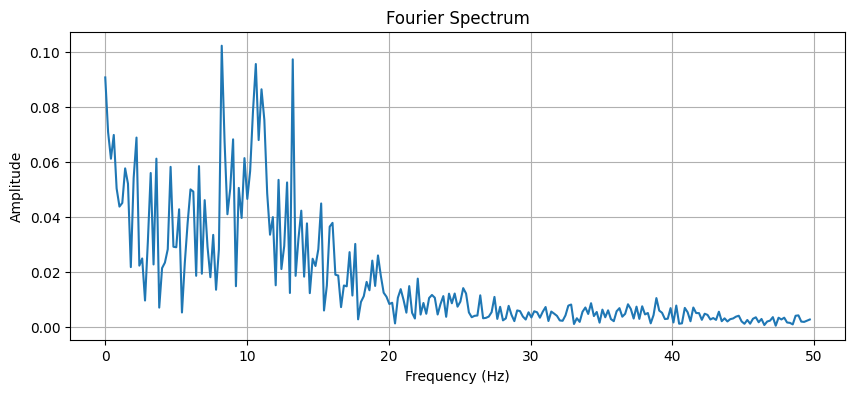

In [7]:
# --- your data ---
# Suppose you already have the list of samples:
# e.g. from your UDP capture
# signal = ax  # or ay, az, etc.
# For testing:
# signal = np.random.randn(500)
signal = ax
signal = np.array(signal)  # ensure it's a NumPy array
N = len(signal)
fs = 100.0  # Hz (10 ms sampling interval)
T = 1.0 / fs

# --- FFT ---
freqs = np.fft.fftfreq(N, T)          # frequency bins
fft_vals = np.fft.fft(signal)         # complex FFT result
fft_magnitude = np.abs(fft_vals) / N  # normalize

# keep only the positive half of spectrum
half = N // 2
freqs = freqs[:half]
fft_magnitude = 2 * fft_magnitude[:half]  # multiply by 2 for one-sided spectrum

# --- Plot ---
plt.figure(figsize=(10, 4))
plt.plot(freqs, fft_magnitude)
plt.title("Fourier Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


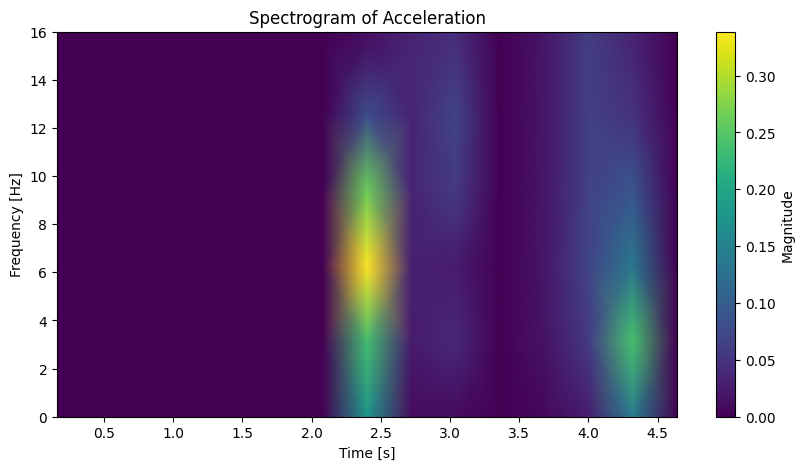

Estimated movement start at t = [2.4] s
1.058852978148867
[0.         0.         0.         0.         0.         0.
 0.         1.3050069  0.34033814 0.51554625 0.         0.30156146
 0.72683182 0.8494528  0.        ]
[7]


In [87]:
from scipy.signal import spectrogram
signal = ax_filt
signal = np.array(signal)  # ensure it's a NumPy array
dt = 0.01               # sampling interval (10 ms)
fs = 1 / dt             # sampling frequency (Hz)

# --- spectrogram ---
# customize windowing here:
window_length_samples = 32          # number of samples per segment
noverlap_samples = 0               # overlap between segments
f, t_spec, Sxx = spectrogram(
    signal,
    fs=fs,
    window='hann',                 # window type: 'hann', 'hamming', 'blackman', etc.
    nperseg=window_length_samples,
    noverlap=noverlap_samples,
    scaling='density',
    mode='magnitude'
)

# --- plot ---
plt.figure(figsize=(10,5))
plt.pcolormesh(t_spec, f, Sxx, shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectrogram of Acceleration')
plt.colorbar(label='Magnitude')
plt.ylim(0, window_length_samples/2)  # optional: limit to relevant frequency range
plt.show()

energy_t = Sxx.sum(axis=0)

# threshold for movement start
threshold = energy_t.mean() + 2*energy_t.std()
movement_indices = np.where(energy_t > threshold)[0]
movement_time = t_spec[movement_indices] if len(movement_indices) > 0 else None
print("Estimated movement start at t =", movement_time, "s")
print(threshold)
print(energy_t)
print(movement_indices)


In [ ]:


## Option B: Plot rotation only
# plt.figure(figsize=(10, 4))
# plt.plot(timestamps, rx, label="rx")
# plt.plot(timestamps, ry, label="ry")
# plt.plot(timestamps, rz, label="rz")
# plt.title("Rotation (°)")
# plt.xlabel("Time (s)")
# plt.ylabel("Degrees")
# plt.legend()
# plt.grid(True)

# fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6))

# a1.plot(timestamps, ax, label="ax")
# a1.plot(timestamps, ay, label="ay")
# a1.plot(timestamps, az, label="az")
# a1.set_title("Acceleration (m/s²)")
# a1.set_xlabel("Time (s)")
# a1.legend()
# a1.grid(True)

# a2.plot(timestamps, rx, label="rx")
# a2.plot(timestamps, ry, label="ry")
# a2.plot(timestamps, rz, label="rz")
# a2.set_title("Rotation (°)")
# a2.set_xlabel("Time (s)")
# a2.legend()
# a2.grid(True)

# plt.tight_layout()
# plt.show()

# Creating dataset
3 accel values applying IIR filter alpha=0.5  
1 magnitude accel raw data  
3 game rotation values from BNO0080  
5 seconds of capture each 10 ms  
Saved in a .csv file 
1rts 600 data values-Evaluate
2nd 2500 data values

In [1]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from tensorflow.keras import layers, models
import tensorflow as tf
import pandas as pd
import os, random
import math
base_dir = os.getcwd()
samples_dir = os.path.join(base_dir, 'CreatedDatasets')

## Data acquisition

In [29]:
def filter (actual, previous, alpha):
    return actual*(1-alpha) + alpha*previous

In [36]:
fileName = 'BNO0080x_movement'
f = os.path.join(samples_dir, 'sensor_{}.csv'.format(fileName))
if os.path.exists(f):
    print('File exists and data will be appended...')
    xyz_df = pd.read_csv(f)
else:
    print('New sample, starting blank...')
    xyz_df = pd.DataFrame(columns=['AX', 'AY', 'AZ', 'MA', 'RX', 'RY', 'RZ' ])

alpha = 0.5 ####################  No olvidar revisar este valor!!!
DURATION = 310 # en segundos. 10 segundos más de lo deseado
ts = 0.010
samples = int(DURATION / ts)
print("Gathering data")
ax, ay, az, ma, rx, ry, rz = [], [], [], [], [], [], []
pax, pay, paz = 0,0,0
sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
sock.settimeout(10.0)
sock.bind((UDP_IP, UDP_PORT))
t0 = time.time()
while time.time() - t0 < DURATION:
    data, addr = sock.recvfrom(1024)
    try:
        decoded = data.decode().strip()
        values = [float(v) for v in decoded.split(",")]

        if len(values) == 6:
            ts = time.time() - t0
            ax.append(filter(values[0], pax, alpha)); ay.append(filter(values[1], pay, alpha)); az.append(filter(values[2], paz, alpha))
            ma.append(math.sqrt(values[0]**2 + values[1]**2 + values[2]**2))
            rx.append(values[3]); ry.append(values[4]); rz.append(values[5])

            pax, pay, paz = values[0], values[1], values[2]

    except Exception as e:
        print(f"Decode error: {e}, raw data: {data}")


sock.close()
new_df = pd.DataFrame({
'AX':ax[:samples], 'AY':ay[:samples], 'AZ':az[:samples], 
'MA':ma[:samples], 
'RX':rx[:samples], 'RY':ry[:samples], 'RZ':rz[:samples] 
})
print('New data acquired:\n', new_df.describe())
xyz_df = pd.concat([xyz_df, new_df], ignore_index=True)
print('Total Data count:', int(xyz_df.shape[0]))

print(f"Received {len(ax)} samples.")
print('Saving data to:', f)
print('Total data of sample {}:\n'.format(fileName), xyz_df.describe())
xyz_df.to_csv(f, index=False)

New sample, starting blank...
Gathering data
New data acquired:
                  AX            AY            AZ            MA            RX  \
count  30719.000000  30719.000000  30719.000000  30719.000000  30719.000000   
mean      -0.038801     -0.004854     -0.053039      1.066352     -3.802840   
std        0.888631      0.661019      0.618153      0.743802     12.801658   
min       -4.620000     -4.595000     -4.085000      0.010000    -77.760000   
25%       -0.470000     -0.340000     -0.345000      0.524023     -9.480000   
50%       -0.025000     -0.005000     -0.060000      0.871206     -3.620000   
75%        0.390000      0.350000      0.210000      1.419137      2.010000   
max        5.465000      4.075000      4.615000      7.207621     71.620000   

                 RY            RZ  
count  30719.000000  30719.000000  
mean       4.881614     -4.705768  
std       20.416614     63.249951  
min      -58.540000   -179.920000  
25%       -6.930000    -26.920000  
50%    

C:\Users\cris_\AppData\Local\Temp\ipykernel_30252\792679041.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  xyz_df = pd.concat([xyz_df, new_df], ignore_index=True)


## Load data and preprocessing
Load all stillness samples

In [3]:
file = "sensor_BNO0080x_stillness.csv"
featuresCount = 7
stride = 28
data = []

df = pd.read_csv(os.path.join(samples_dir, file))
ax = df['AX'].to_numpy()
ay = df['AY'].to_numpy()
az = df['AZ'].to_numpy()
ma = df['MA'].to_numpy()
rx = df['RX'].to_numpy()
ry = df['RY'].to_numpy()
rz = df['RZ'].to_numpy()

for i in range(int(df.shape[0]/stride)):
    base_idx = i * stride
    batch = np.array([ax[base_idx:base_idx+stride], ay[base_idx:base_idx+stride], az[base_idx:base_idx+stride], 
                    ma[base_idx:base_idx+stride],
                    rx[base_idx:base_idx+stride], ry[base_idx:base_idx+stride], rz[base_idx:base_idx+stride]])
    batch = batch.reshape((featuresCount, stride)).T
    data.append(batch)
    
print('Added {} data to the data list'.format(file))
print(len(data))

Added sensor_BNO0080x_stillness.csv data to the data list
3387


Let's plot one data sample.

<Figure size 640x480 with 0 Axes>

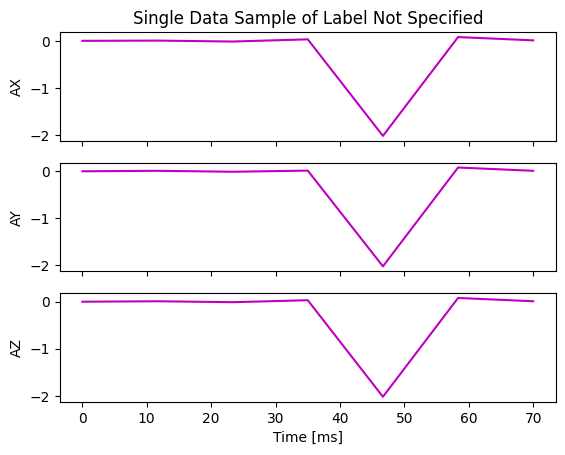

In [4]:
def plot_single_sample(data_sample, label='Not Specified'):
    plt.clf()
    fig, axs = plt.subplots(3)
    t = np.linspace(0, data_sample.shape[1] * 10, data_sample.shape[1]) #Accelerometer sampled with 10ms
    axs[0].set_title(label='Single Data Sample of Label {}'.format(label))
    axs[0].plot(t, data_sample[0], c='m')
    axs[0].set_ylabel('AX')
    plt.setp(axs[0].get_xticklabels(), visible=False)
    axs[1].plot(t, data_sample[1], c='m')
    axs[1].set_ylabel('AY')
    plt.setp(axs[1].get_xticklabels(), visible=False)
    axs[2].plot(t, data_sample[2], c='m')
    axs[2].set_ylabel('AZ')
    plt.xlabel('Time [ms]')
    plt.show()

    
#idx = random.randint(0, len(data)-1)
idx = 0
plot_single_sample(data_sample=data[idx])

In [4]:
print(np.array(data).shape)
print(np.array(data)[0][0])

(3387, 28, 7)
[ 0.          0.005      -0.015       0.03162278 -2.02        0.08
  0.01      ]


In [5]:
x_train, x_test = train_test_split(np.array(data), test_size=0.2, random_state=42)
x_test, x_val = train_test_split(np.array(x_test), test_size=0.5, random_state=42)
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(2709, 28, 7)
(339, 28, 7)
(339, 28, 7)


In [6]:
###Normalized data

mean = x_train.mean(axis=(0,1), keepdims=True)
std = x_train.std(axis=(0,1), keepdims=True) + 1e-8
print("Train mean:", mean)
print("Train std:", std)

# --- normalize all sets ---
x_train = (x_train - mean) / std
x_val = (x_val - mean) / std
x_test = (x_test - mean) / std


Train mean: [[[ 9.79341349e-04  3.91486052e-04 -2.36249539e-03  1.69625087e-01
   -3.55466817e+00 -2.41194458e+00 -5.22748352e+00]]]
Train std: [[[ 0.1180995   0.11366158  0.10483864  0.13476092 11.20250486
   12.22155535 62.58441196]]]


# NN Model creation and training
Here, we create a neural network and train it! It is very small and simple.

In [22]:
#Model 1: Rows timesteps, columns features
tf.keras.backend.clear_session() 
def build_conv_ae(timesteps, channels=7, latent_dim=16):
    inp = layers.Input((timesteps, channels))
    x = layers.Conv1D(16, kernel_size=3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(2)(x)  # timesteps/2
    x = layers.Conv1D(32, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(2)(x)  # timesteps/4
    x = layers.Flatten()(x)
    encoded = layers.Dense(latent_dim, activation='relu')(x)

    # Decoder
    x = layers.Dense((timesteps//4)*32, activation='relu')(encoded)
    x = layers.Reshape((timesteps//4, 32))(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(16, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.UpSampling1D(2)(x)
    decoded = layers.Conv1D(channels, kernel_size=3, padding='same', activation='linear')(x)

    model = models.Model(inp, decoded)
    #model.compile(optimizer='adam', loss='mse')
    return model


In [23]:
tf.keras.backend.clear_session() 
modelCNN_AE = build_conv_ae(stride)
modelCNN_AE.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 7)]           0         
                                                                 
 conv1d (Conv1D)             (None, 28, 16)            352       
                                                                 
 batch_normalization (BatchN  (None, 28, 16)           64        
 ormalization)                                                   
                                                                 
 max_pooling1d (MaxPooling1D  (None, 14, 16)           0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 14, 32)            1568      
                                                                 
 batch_normalization_1 (Batc  (None, 14, 32)           128   

In [24]:
batch = 32
modelCNN_AE.compile(optimizer='adam', loss='mse', metrics=['accuracy'])
history = modelCNN_AE.fit(x_train, x_train, batch_size=batch, epochs=600, validation_data=(x_val, x_val))

Epoch 1/600
85/85 [==============================] - 1s 5ms/step - loss: 0.8913 - accuracy: 0.2101 - val_loss: 0.7911 - val_accuracy: 0.2364
Epoch 2/600
85/85 [==============================] - 0s 4ms/step - loss: 0.6623 - accuracy: 0.3145 - val_loss: 0.6468 - val_accuracy: 0.3124
Epoch 3/600
85/85 [==============================] - 0s 4ms/step - loss: 0.5865 - accuracy: 0.3699 - val_loss: 0.5936 - val_accuracy: 0.3334
Epoch 4/600
85/85 [==============================] - 0s 4ms/step - loss: 0.5584 - accuracy: 0.3863 - val_loss: 0.5584 - val_accuracy: 0.3723
Epoch 5/600
85/85 [==============================] - 0s 6ms/step - loss: 0.5279 - accuracy: 0.4139 - val_loss: 0.5286 - val_accuracy: 0.3902
Epoch 6/600
85/85 [==============================] - 0s 3ms/step - loss: 0.5019 - accuracy: 0.4301 - val_loss: 0.5088 - val_accuracy: 0.4181
Epoch 7/600
85/85 [==============================] - 0s 4ms/step - loss: 0.4797 - accuracy: 0.4513 - val_loss: 0.4921 - val_accuracy: 0.4302
Epoch 8/600
8

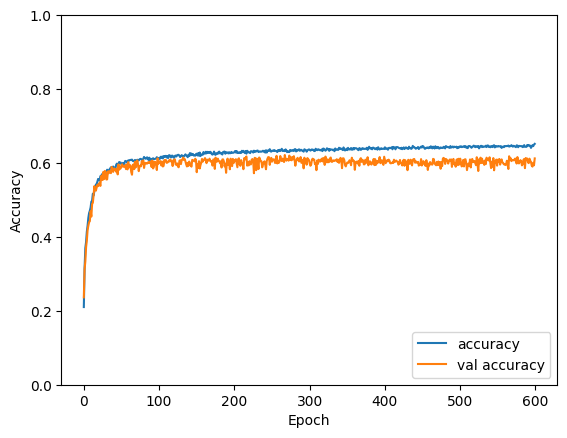

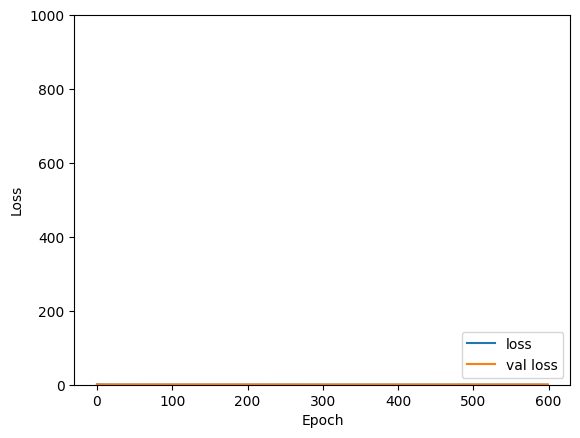

In [25]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

plt.figure()
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1000])
plt.legend(loc='lower right')

In [26]:
score_train = modelCNN_AE.evaluate(x_train, x_train, verbose=1)
score_test = modelCNN_AE.evaluate(x_test, x_test, verbose=1)
score_val = modelCNN_AE.evaluate(x_val, x_val, verbose=1)

print("Score test:", score_train)
print("Score test:", score_test)
print("Score validation:", score_val)



11/11 [==============================] - 0s 2ms/step - loss: 0.3139 - accuracy: 0.6123
Score test: [0.2142883986234665, 0.6639112830162048]
Score test: [0.26860564947128296, 0.6253687143325806]
Score validation: [0.3138834536075592, 0.6123051047325134]


11/11 [==============================] - 0s 2ms/step


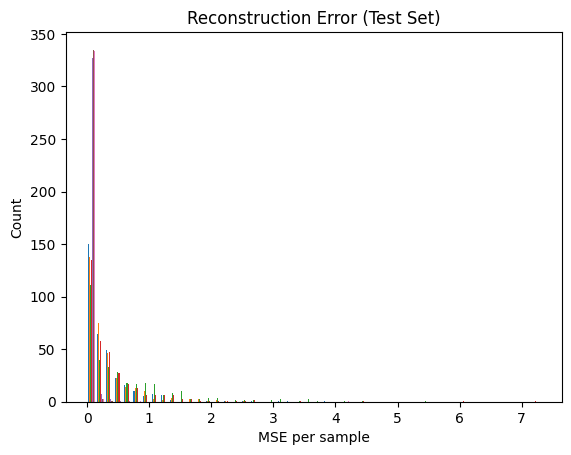

Moving threshold: 1.8909050162151297


In [27]:
reconstructed = modelCNN_AE.predict(x_test)
errors = np.mean(np.square(x_test - reconstructed), axis=1)

plt.hist(errors, bins=50)
plt.title("Reconstruction Error (Test Set)")
plt.xlabel("MSE per sample")
plt.ylabel("Count")
plt.show()

threshold = np.mean(errors) + 3*np.std(errors) # above it → “moving.”
print ("Moving threshold:", threshold)

In [28]:
#Data for testing
file = "sensor_BNO0080x_movement.csv"
featuresCount = 7
stride = 28
offsetStart = 0
samplesNumber = 300
data_m = []

df = pd.read_csv(os.path.join(samples_dir, file))
ax = df['AX'].to_numpy()
ay = df['AY'].to_numpy()
az = df['AZ'].to_numpy()
ma = df['MA'].to_numpy()
rx = df['RX'].to_numpy()
ry = df['RY'].to_numpy()
rz = df['RZ'].to_numpy()

for i in range(int(df.shape[0]/stride)):
    base_idx = i * stride
    batch = np.array([ax[base_idx:base_idx+stride], ay[base_idx:base_idx+stride], az[base_idx:base_idx+stride], 
                    ma[base_idx:base_idx+stride],
                    rx[base_idx:base_idx+stride], ry[base_idx:base_idx+stride], rz[base_idx:base_idx+stride]])
    batch = batch.reshape((featuresCount, stride)).T
    data_m.append(batch)
    
print('Added {} data to the data list'.format(file))
print(len(data_m))
x_test_mov = np.array(data_m)
indices = np.arange(len(x_test_mov))
np.random.shuffle(indices)
x_test_mov = x_test_mov[indices]
x_test_mov = x_test_mov[offsetStart:offsetStart+samplesNumber]
x_test_mov = (x_test_mov-mean)/std
print(x_test_mov.shape)

Added sensor_BNO0080x_movement.csv data to the data list
1097
(300, 28, 7)


In [29]:
# 1. Combine both sets vertically (stack one after another)
X_test = np.concatenate([x_test[:300], x_test_mov], axis=0)

# 2. Create matching labels
y_test_still = np.zeros(len(x_test[:300]))  # 0 = still
y_test_move  = np.ones(len(x_test_mov))    # 1 = moving
y_test = np.concatenate([y_test_still, y_test_move])

# Optional: Shuffle (so model doesn’t see all still first then all moving)
indices = np.arange(len(X_test))
np.random.shuffle(indices)
X_test = X_test[indices]
y_test = y_test[indices]

print(X_test.shape)  # (600, 30, 7)
print(y_test.shape)  # (600,)


(600, 28, 7)
(600,)


19/19 [==============================] - 0s 3ms/step
Counts: TP, FP, TN, FN = 291 21 279 9
Precision: 0.9327, Recall: 0.9700, F1: 0.9510, FPR: 0.0700
AUC (error as score): 0.9903


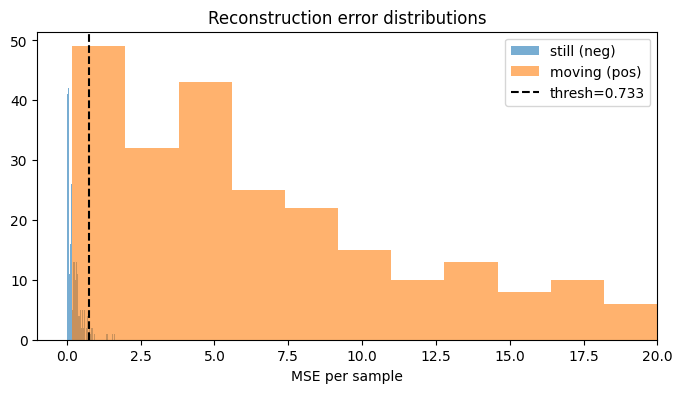

In [32]:
# Predict and compute per-sample reconstruction error (MSE per sample)
reconstructed = modelCNN_AE.predict(X_test)
# If your model outputs same shape as input:
mse_per_sample = np.mean(np.square(X_test - reconstructed), axis=tuple(range(1, X_test.ndim)))  # collapse feature/time dims -> shape (N,)

# Use your threshold - adapt if your mse units differ
threshold = 0.733
y_pred = (mse_per_sample > threshold).astype(int)

# Metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
tpr = recall

print("Counts: TP, FP, TN, FN =", tp, fp, tn, fn)
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, FPR: {fpr:.4f}")

# ROC / threshold tuning (optional)
try:
    auc = roc_auc_score(y_test, mse_per_sample)
    print(f"AUC (error as score): {auc:.4f}")
except Exception as e:
    print("Could not compute AUC:", e)

# Visuals
plt.figure(figsize=(8,4))
plt.hist(mse_per_sample[y_test==0], bins=80, alpha=0.6, label='still (neg)')
plt.hist(mse_per_sample[y_test==1], bins=80, alpha=0.6, label='moving (pos)')
plt.axvline(threshold, color='k', linestyle='--', label=f'thresh={threshold}')
plt.legend()
plt.title("Reconstruction error distributions")
plt.xlabel("MSE per sample")
plt.xlim(-1, 20)
plt.show()

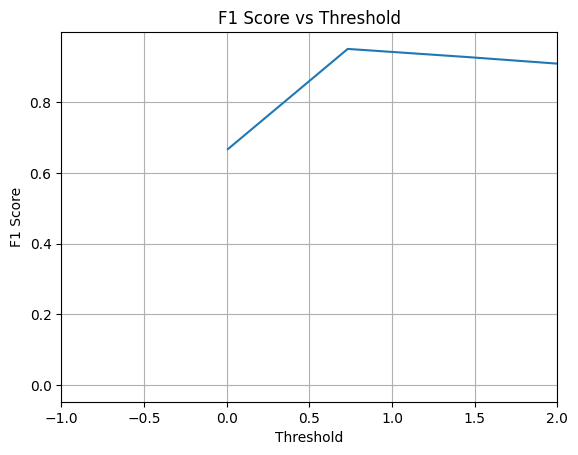

Best threshold: 0.732516151150498


In [31]:
ths = np.linspace(min(mse_per_sample), max(mse_per_sample), 200)
scores = [f1_score(y_test, mse_per_sample > t) for t in ths]
best_t = ths[np.argmax(scores)]

plt.plot(ths, scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")
plt.grid(True)
plt.xlim(-1,2)
plt.show()
print("Best threshold:", best_t)

In [ ]:
# modelName = "Models/4_f2_95_auc_99/4_AE_28_7_n_f195"
# modelCNN_AE.save(modelName)
# modelCNN_AE.save(modelName+".h5")
# converter = tf.lite.TFLiteConverter.from_keras_model(modelCNN_AE)
# tflite_model = converter.convert()

# # Save TFLite file
# with open(modelName+".tflite", "wb") as f:
#     f.write(tflite_model)

# np.savez(modelName+".npz", mean=mean, std=std)

INFO:tensorflow:Assets written to: Models/4_f2_95_auc_99/4_AE_28_7_n_f195\assets


INFO:tensorflow:Assets written to: Models/4_f2_95_auc_99/4_AE_28_7_n_f195\assets


INFO:tensorflow:Assets written to: C:\Users\cris_\AppData\Local\Temp\tmpyj36kg9t\assets


INFO:tensorflow:Assets written to: C:\Users\cris_\AppData\Local\Temp\tmpyj36kg9t\assets


In [7]:
#Load prevoious data
from tensorflow.keras.models import load_model
#model = load_model("AE_model_full")
#model = load_model("AE_model.h5")
interpreter = tf.lite.Interpreter(model_path="Models/4_f2_95_auc_99/4_AE_28_7_n_f195.tflite")
interpreter.allocate_tensors()
#for d in interpreter.get_tensor_details():
#    print(d["name"], d["dtype"], d["shape"])
#print("Used ops:", interpreter._get_ops_details())

print("Model Operators:")
for op in interpreter._get_ops_details():
    print(op["op_name"])


params = np.load("normalization_params.npz")
mean = params["mean"]
std = params["std"]

Model Operators:
EXPAND_DIMS
CONV_2D
MUL
ADD
RESHAPE
EXPAND_DIMS
MAX_POOL_2D
RESHAPE
EXPAND_DIMS
CONV_2D
MUL
ADD
RESHAPE
EXPAND_DIMS
MAX_POOL_2D
RESHAPE
FULLY_CONNECTED
FULLY_CONNECTED
SHAPE
STRIDED_SLICE
PACK
RESHAPE
SPLIT
CONCATENATION
EXPAND_DIMS
CONV_2D
RESHAPE
SPLIT
CONCATENATION
EXPAND_DIMS
CONV_2D
RESHAPE


NameError: name 'np' is not defined

In [ ]:
#######TBD
